# Load & Clean Data

---

In [ ]:
import pandas as pd
import numpy as np

---
## Load Data
---

### 1. Import .csv source files into Pandas dataframes.

In [ ]:
# Import Products.csv and create products_df
products_df = pd.read_csv('Products.csv')

# Import Shipping.csv and create shipping_df
shipping_df = pd.read_csv('Shipping.csv')

# Import Stores.csv and create stores_df1
stores_df1 = pd.read_csv('Stores.csv')

# Import Transactions.csv and create transactions_df
transactions_df = pd.read_csv('Transactions.csv')

In [3]:
products_df.head(2)

,ProductID,Name,Price,Cost
0,1,"Sweater,Blue",30,10
1,2,"Sweater,Black",35,10


In [4]:
stores_df1.isna().sum()

StoreID    10
City        0
dtype: int64

### 2. Check for null values in the four dataframes.

In [5]:
# Create files list containing the four dataframes
files = [products_df, shipping_df, stores_df1, transactions_df]

# Loop through the files list and print the sum of null values
for i in files:
    print(i.isnull().sum())

ProductID    0
Name         0
Price        0
Cost         0
dtype: int64
OrderID           0
City              0
ShippingMethod    9
dtype: int64
StoreID    10
City        0
dtype: int64
ProductID    0
Year         0
Month        0
Day          0
Quantity     0
OrderLine    0
OrderID      0
dtype: int64


### 3. Fill in the null values of the StoreID column.

In [6]:
# Print stores_df1
stores_df1

,StoreID,City
0,NaN,Surrey
1,NaN,Langley
2,NaN,Vancouver
3,NaN,Burnaby
4,NaN,Los Angeles
5,NaN,New York
6,NaN,Portland
7,NaN,Utah
8,NaN,Seattle
9,NaN,Kelowna


In [7]:
# Create a list of sequential numbers from 1 to 10
storeIDs = list(range(1,11))

# Create a for loop that assigns each of the items from the list to the StoreID column of stores_df1
for i in stores_df1['StoreID'].index:
    stores_df1['StoreID'] = storeIDs[i]

In [8]:
storeIDs = list(range(1, 11))

for i in stores_df1.index:
    stores_df1.at[i, 'StoreID'] = storeIDs[i]

In [9]:
stores_df1

,StoreID,City
0,1,Surrey
1,2,Langley
2,3,Vancouver
3,4,Burnaby
4,5,Los Angeles
5,6,New York
6,7,Portland
7,8,Utah
8,9,Seattle
9,10,Kelowna


In [10]:
# Print stores_df1 to check the results of the for loop
stores_df1.isna().sum()

StoreID    0
City       0
dtype: int64

### 4. Fill in the null values of the ShippingMethod column with 'Expediated'.

In [11]:
# Identify the unique values and count of rows in the ShippingMethod column
shipping_df['ShippingMethod'].value_counts(dropna = False)  

ShippingMethod
Standard     535
Expedited     55
Nextday       55
NaN            9
Name: count, dtype: int64

In [ ]:
# Fill the na values with 'Expediated'
shipping_df['ShippingMethod'] = shipping_df['ShippingMethod'].fillna('Expedited')

In [13]:
# Check the unique values and counts
shipping_df['ShippingMethod'].value_counts(dropna = False)

ShippingMethod
Standard     535
Expedited     64
Nextday       55
Name: count, dtype: int64

---
## Clean Data
---

### 5. Create stores_df2 dataframe from a dictionary containing two lists.

In [14]:
# Create and print storeIDs and cities lists
storeIDs2 = list(range(11,16))
cities = ['Seoul','Tokyo','Denver','Miami','San Diego']

print(storeIDs2)
print(cities)

[11, 12, 13, 14, 15]
['Seoul', 'Tokyo', 'Denver', 'Miami', 'San Diego']


In [15]:
# Create and print stores_dict dictionary with the storeIDs and cities lists
stores_dict = {'StoreID': storeIDs2,
         'City': cities}
stores_dict

{'StoreID': [11, 12, 13, 14, 15],
 'City': ['Seoul', 'Tokyo', 'Denver', 'Miami', 'San Diego']}

In [16]:
# Create and print stores_df2 dataframe from the stores_dict dictionary
stores_df2 = pd.DataFrame(data=stores_dict)
stores_df2

,StoreID,City
0,11,Seoul
1,12,Tokyo
2,13,Denver
3,14,Miami
4,15,San Diego


In [17]:
stores_df2

,StoreID,City
0,11,Seoul
1,12,Tokyo
2,13,Denver
3,14,Miami
4,15,San Diego


### 6. Concatenate stores_df1 and stores_df2 to create store_df.

In [18]:
# Create stores_df by concatenating the stores_df1 and stores_df2 dataframes
stores_df = pd.concat([stores_df1, stores_df2]).reset_index(drop='index')

In [19]:
# Print stores_df to check the results of the concatenation
stores_df

,StoreID,City
0,1,Surrey
1,2,Langley
2,3,Vancouver
3,4,Burnaby
4,5,Los Angeles
5,6,New York
6,7,Portland
7,8,Utah
8,9,Seattle
9,10,Kelowna


### 7. Identify and drop duplicate rows from transactions_df.

In [20]:
transactions_df[transactions_df.duplicated()]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID
122,20,2019,11,7,4,122,122
123,20,2019,11,7,4,122,122
124,20,2019,11,7,4,122,122
125,20,2019,11,7,4,122,122
126,20,2019,11,7,4,122,122
127,20,2019,11,7,4,122,122
128,20,2019,11,7,4,122,122


In [21]:
# Identify duplicate rows in transactions_df
transactions_df[transactions_df.duplicated()]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID
122,20,2019,11,7,4,122,122
123,20,2019,11,7,4,122,122
124,20,2019,11,7,4,122,122
125,20,2019,11,7,4,122,122
126,20,2019,11,7,4,122,122
127,20,2019,11,7,4,122,122
128,20,2019,11,7,4,122,122


In [22]:
# Drop duplicate rows in transactions_df
transactions_df = transactions_df.drop_duplicates()

In [23]:
# Print transactions_df to check the results of dropping duplicates
transactions_df[transactions_df.duplicated()]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID


### 8. Modify the column data types in shipping_df & transactions_df.

In [24]:
# Identify the data types in shipping_df & transactions_df|
shipping_df.info()
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         654 non-null    float64
 1   City            654 non-null    str    
 2   ShippingMethod  654 non-null    str    
dtypes: float64(1), str(2)
memory usage: 25.4 KB
<class 'pandas.DataFrame'>
Index: 654 entries, 0 to 660
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  654 non-null    int64
 1   Year       654 non-null    int64
 2   Month      654 non-null    int64
 3   Day        654 non-null    int64
 4   Quantity   654 non-null    int64
 5   OrderLine  654 non-null    int64
 6   OrderID    654 non-null    int64
dtypes: int64(7)
memory usage: 40.9 KB


In [25]:
transactions_df.dtypes

ProductID    int64
Year         int64
Month        int64
Day          int64
Quantity     int64
OrderLine    int64
OrderID      int64
dtype: object

In [26]:
# Change the data type of OrderID to integer
shipping_df['OrderID'] = shipping_df['OrderID'].astype('int')

In [27]:
# Change the data type of Year, Month, and Day to string
transactions_df['Year'] = transactions_df['Year'].astype('str')
transactions_df['Month'] = transactions_df['Month'].astype('str')
transactions_df['Day'] = transactions_df['Day'].astype('str')

In [28]:
# Print shipping_df & transactions_df to check the results of the change in data type
shipping_df.info()
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   OrderID         654 non-null    int64
 1   City            654 non-null    str  
 2   ShippingMethod  654 non-null    str  
dtypes: int64(1), str(2)
memory usage: 25.4 KB
<class 'pandas.DataFrame'>
Index: 654 entries, 0 to 660
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  654 non-null    int64
 1   Year       654 non-null    str  
 2   Month      654 non-null    str  
 3   Day        654 non-null    str  
 4   Quantity   654 non-null    int64
 5   OrderLine  654 non-null    int64
 6   OrderID    654 non-null    int64
dtypes: int64(4), str(3)
memory usage: 45.3 KB


### 9. Split the Name column into two columns: Type and Colour.

In [29]:
# View the top 5 rows of products_df
products_df.head(2)

,ProductID,Name,Price,Cost
0,1,"Sweater,Blue",30,10
1,2,"Sweater,Black",35,10


In [30]:
# Create Type and Colour columns by splitting the Name column
products_df['Type'] = products_df['Name'].str.split(',', expand=True)[0]
products_df['Colour'] = products_df['Name'].str.split(',', expand=True)[1]

In [31]:
# Print the top 5 rows of products_df to check the new columns
products_df.head()

,ProductID,Name,Price,Cost,Type,Colour
0,1,"Sweater,Blue",30,10,Sweater,Blue
1,2,"Sweater,Black",35,10,Sweater,Black
2,3,"Sweater,White",30,10,Sweater,White
3,4,"Hoodie,Black",40,15,Hoodie,Black
4,5,"Hoodie,White",35,15,Hoodie,White


In [32]:
products_df['Colour'].value_counts()

Colour
Black    5
White    5
Blue     3
Gray     2
Grey     2
Green    2
Red      1
Name: count, dtype: int64

### 10. Replace the 'Gray' values of the Colour column with 'Grey'.

In [33]:
# Identify the unique values of Colour
products_df['Colour'].unique()

<ArrowStringArray>
['Blue', 'Black', 'White', 'Gray', 'Grey', 'Green', 'Red']
Length: 7, dtype: str

In [34]:
# Replace the values of 'Gray' with 'Grey'
products_df['Colour'] = products_df['Colour'].str.replace('Gray','Grey')

In [35]:
# Review the new unique values of Colour
products_df['Colour'].unique()

<ArrowStringArray>
['Blue', 'Black', 'White', 'Grey', 'Green', 'Red']
Length: 6, dtype: str

---
## Transform Data
---

### 11. Create orders_df by merging transactions_df, products_df, shipping_df, and stores_df.

In [36]:
transactions_df.head(2)
products_df.head(2)

,ProductID,Name,Price,Cost,Type,Colour
0,1,"Sweater,Blue",30,10,Sweater,Blue
1,2,"Sweater,Black",35,10,Sweater,Black


In [37]:
# Merge transactions_df & products_df - returning all matching rows to the transactions_df
orders_df = pd.merge(transactions_df, products_df, on = 'ProductID', how = 'left')
orders_df.head(3)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,Sweater,White
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,T-shirt,Black
2,1,2019,1,6,1,3,3,"Sweater,Blue",30,10,Sweater,Blue


In [38]:
# Merge shipping_df & stores_df - returning only matching rows in both dataframes
shipping_stores_df = pd.merge(shipping_df, stores_df, on = 'City', how = 'inner')
shipping_stores_df.head(3)

,OrderID,City,ShippingMethod,StoreID
0,1,Vancouver,Standard,3
1,2,Los Angeles,Expedited,5
2,3,Burnaby,Standard,4


In [39]:
# Merge orders_df & shipping_stores_df - returning only matching rows from the shipping_stores_df
orders_df = pd.merge(orders_df, shipping_stores_df, on = 'OrderID', how = 'right')

In [40]:
# Print orders_df to inspect the new dataframe
orders_df.head(3)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,Sweater,White,Vancouver,Standard,3
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,T-shirt,Black,Los Angeles,Expedited,5
2,1,2019,1,6,1,3,3,"Sweater,Blue",30,10,Sweater,Blue,Burnaby,Standard,4


### 12. Create a new column, Date, from the Year, Month, and Day columns in orders_df.

In [41]:
# Create Date column
orders_df['Date'] = orders_df['Year'] +"-"+ orders_df['Month'] +"-"+ orders_df['Day']

In [42]:
orders_df.dtypes

ProductID         int64
Year                str
Month               str
Day                 str
Quantity          int64
OrderLine         int64
OrderID           int64
Name                str
Price             int64
Cost              int64
Type                str
Colour              str
City                str
ShippingMethod      str
StoreID           int64
Date                str
dtype: object

In [43]:
# Set the data type to 'datetime64[ns]'
orders_df['Date'] = orders_df['Date'].astype('datetime64[ns]')

In [44]:
# Inspect orders_df to check the new column
orders_df.head(2)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,Sweater,White,Vancouver,Standard,3,2019-01-02
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,T-shirt,Black,Los Angeles,Expedited,5,2019-01-06


### 13. Create a new column, Discount Pct, in orders_df. The column should indicate a 30% discount to socks that are either green or grey.

In [45]:
# WHERE 
#     (condition , Value if True, Value if False)

In [46]:
orders_df.tail(5)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date
598,13,2022,7,9,1,650,650,"Socks,Grey",10,1,Socks,Grey,Langley,Standard,2,2022-07-09
599,5,2022,7,31,3,651,651,"Hoodie,White",35,15,Hoodie,White,Langley,Standard,2,2022-07-31
600,7,2022,9,3,1,652,652,"T-shirt,White",15,2,T-shirt,White,Langley,Standard,2,2022-09-03
601,7,2022,10,29,2,653,653,"T-shirt,White",15,2,T-shirt,White,Langley,Standard,2,2022-10-29
602,7,2022,12,3,1,654,654,"T-shirt,White",15,2,T-shirt,White,Langley,Standard,2,2022-12-03


In [47]:
orders_df[orders_df['Type'] == 'Socks']

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date
8,14,2019,1,28,5,9,9,"Socks,Green",10,1,Socks,Green,Burnaby,Standard,4,2019-01-28
10,11,2019,1,31,3,11,11,"Socks,White",10,1,Socks,White,New York,Standard,6,2019-01-31
18,11,2019,2,12,1,19,19,"Socks,White",10,1,Socks,White,Burnaby,Standard,4,2019-02-12
25,13,2019,2,27,2,26,26,"Socks,Grey",10,1,Socks,Grey,Langley,Standard,2,2019-02-27
62,13,2019,5,26,4,63,63,"Socks,Grey",10,1,Socks,Grey,Seoul,Standard,11,2019-05-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,13,2021,2,7,5,617,617,"Socks,Grey",10,1,Socks,Grey,Langley,Standard,2,2021-02-07
568,14,2021,3,6,3,620,620,"Socks,Green",10,1,Socks,Green,Langley,Standard,2,2021-03-06
572,12,2021,4,21,2,624,624,"Socks,Black",15,1,Socks,Black,Langley,Standard,2,2021-04-21
587,14,2021,10,17,5,639,639,"Socks,Green",10,1,Socks,Green,Langley,Standard,2,2021-10-17


In [48]:
# Create Discount Pct column
orders_df['Discount Pct'] = np.where(
    (
        (orders_df['Type'] == 'Socks') & 
        ((orders_df['Colour'] == 'Green') | (orders_df['Colour'] == 'Grey'))
    )
    , 30, 0)

In [49]:
orders_df.sample(5)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct
55,10,2019,5,9,2,56,56,"T-shirt,Blue",15,2,T-shirt,Blue,Seoul,Nextday,11,2019-05-09,0
265,1,2020,12,27,4,277,277,"Sweater,Blue",30,10,Sweater,Blue,Burnaby,Expedited,4,2020-12-27,0
545,14,2022,12,17,1,597,597,"Socks,Green",10,1,Socks,Green,Vancouver,Standard,3,2022-12-17,30
593,5,2022,2,27,3,645,645,"Hoodie,White",35,15,Hoodie,White,Langley,Standard,2,2022-02-27,0
68,7,2019,6,14,3,69,69,"T-shirt,White",15,2,T-shirt,White,Surrey,Expedited,1,2019-06-14,0


In [50]:
# Print orders_df where the rows have a Type of 'Socks'
orders_df[(orders_df['Type'] == 'Socks')].head(8)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct
8,14,2019,1,28,5,9,9,"Socks,Green",10,1,Socks,Green,Burnaby,Standard,4,2019-01-28,30
10,11,2019,1,31,3,11,11,"Socks,White",10,1,Socks,White,New York,Standard,6,2019-01-31,0
18,11,2019,2,12,1,19,19,"Socks,White",10,1,Socks,White,Burnaby,Standard,4,2019-02-12,0
25,13,2019,2,27,2,26,26,"Socks,Grey",10,1,Socks,Grey,Langley,Standard,2,2019-02-27,30
62,13,2019,5,26,4,63,63,"Socks,Grey",10,1,Socks,Grey,Seoul,Standard,11,2019-05-26,30
73,12,2019,6,26,3,74,74,"Socks,Black",15,1,Socks,Black,Vancouver,Standard,3,2019-06-26,0
79,12,2019,7,6,5,80,80,"Socks,Black",15,1,Socks,Black,Vancouver,Standard,3,2019-07-06,0
101,13,2019,9,5,2,104,104,"Socks,Grey",10,1,Socks,Grey,Los Angeles,Expedited,5,2019-09-05,30


### 14. Create five new columns in orders_df.

In [51]:
orders_df.sample(4)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct
243,9,2020,10,14,3,247,247,"T-shirt,Grey",15,2,T-shirt,Grey,Vancouver,Standard,3,2020-10-14,0
24,8,2019,2,26,4,25,25,"T-shirt,Black",20,2,T-shirt,Black,Vancouver,Expedited,3,2019-02-26,0
411,8,2022,2,14,5,453,453,"T-shirt,Black",20,2,T-shirt,Black,Surrey,Standard,1,2022-02-14,0
16,8,2019,2,9,4,16,17,"T-shirt,Black",20,2,T-shirt,Black,Burnaby,Standard,4,2019-02-09,0


In [52]:
# Create Sale Price, calculating the price after a discount has been applied
orders_df['Sale Price'] = orders_df['Price']*(100-orders_df['Discount Pct'])/100

In [53]:
# Create Net Profit, calculating the difference between the Sale Price and Cost
orders_df['Net Profit'] = orders_df['Sale Price']-orders_df['Cost']

In [54]:
# Create Total Revenue, calculating the Sale Price by Quantity
orders_df['Total Revenue'] = orders_df['Sale Price']*orders_df['Quantity']

In [55]:
# Create Total Cost, calculating the Cost by Quantity
orders_df['Total Cost'] = orders_df['Cost']*orders_df['Quantity']

In [56]:
# Create Total Net Profit, calculating the difference between Total Revenue and Total Cost
orders_df['Total Net Profit'] = orders_df['Total Revenue']-orders_df['Total Cost']

In [57]:
# Print orders_df to check the new columns
orders_df.head(4)

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,...,Vancouver,Standard,3,2019-01-02,0,30.0,20.0,60.0,20,40.0
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,...,Los Angeles,Expedited,5,2019-01-06,0,20.0,18.0,60.0,6,54.0
2,1,2019,1,6,1,3,3,"Sweater,Blue",30,10,...,Burnaby,Standard,4,2019-01-06,0,30.0,20.0,30.0,10,20.0
3,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,...,Vancouver,Standard,3,2019-01-09,0,20.0,18.0,80.0,8,72.0


# Analyze & Visualize Data
---

---
## Analyze Data
---

## Store Metrics

### 1. Filter orders_df to return rows from 2019 for Store 1.

In [58]:
# Define the filter condition on the Year and StoreID columns
year_city_filter = (orders_df['Year'] == '2019') & (orders_df['StoreID'] == 1)

# Apply the filter condition to orders_df
orders_df[year_city_filter]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
5,10,2019,1,12,4,5,6,"T-shirt,Blue",15,2,...,Surrey,Standard,1,2019-01-12,0,15.0,13.0,60.0,8,52.0
14,9,2019,2,8,4,15,15,"T-shirt,Grey",15,2,...,Surrey,Standard,1,2019-02-08,0,15.0,13.0,60.0,8,52.0
17,7,2019,2,12,1,18,18,"T-shirt,White",15,2,...,Surrey,Standard,1,2019-02-12,0,15.0,13.0,15.0,2,13.0
21,8,2019,2,18,3,22,22,"T-shirt,Black",20,2,...,Surrey,Standard,1,2019-02-18,0,20.0,18.0,60.0,6,54.0
30,4,2019,3,16,3,31,31,"Hoodie,Black",40,15,...,Surrey,Standard,1,2019-03-16,0,40.0,25.0,120.0,45,75.0
33,8,2019,3,27,4,34,34,"T-shirt,Black",20,2,...,Surrey,Standard,1,2019-03-27,0,20.0,18.0,80.0,8,72.0
36,9,2019,4,2,2,37,37,"T-shirt,Grey",15,2,...,Surrey,Expedited,1,2019-04-02,0,15.0,13.0,30.0,4,26.0
37,6,2019,4,2,1,37,38,"Hoodie,Gray",35,15,...,Surrey,Nextday,1,2019-04-02,0,35.0,20.0,35.0,15,20.0
39,1,2019,4,9,4,40,40,"Sweater,Blue",30,10,...,Surrey,Standard,1,2019-04-09,0,30.0,20.0,120.0,40,80.0
47,8,2019,4,17,3,48,48,"T-shirt,Black",20,2,...,Surrey,Standard,1,2019-04-17,0,20.0,18.0,60.0,6,54.0


### 2. What is the average Total Net Profit across the stores?

In [59]:
# Calculate the Total Net Profit by StoreID
store_profit_df = orders_df.groupby(by='StoreID').agg({'Total Net Profit': 'sum'})
store_profit_df

,Total Net Profit
StoreID,
1,6827.0
2,3915.0
3,8740.0
4,7894.0
5,794.0
6,859.0
7,749.0
9,723.0
10,702.0


In [60]:
# Calculate the average Total Net Profit
store_profit_df['Total Net Profit'].mean()

np.float64(2709.0833333333335)

### 3. Return the number of orders for each Store and City.

In [61]:
orders_df[['StoreID','City','OrderID']].groupby(by=['StoreID','City']).count()

,,OrderID
StoreID,City,
1,Surrey,130
2,Langley,73
3,Vancouver,165
4,Burnaby,139
5,Los Angeles,16
6,New York,14
7,Portland,15
9,Seattle,12
10,Kelowna,10


### 4. Return the Total Cost by Store in descending order.

In [62]:
# Calculate the Total Cost by StoreID
store_cost_df = orders_df[['StoreID','Total Cost']].groupby(by=['StoreID']).sum()
    
# Sort the values by Total Cost in descending order
store_cost_df.sort_values('Total Cost', ascending = False)

,Total Cost
StoreID,
3,3365
4,3314
1,2779
2,1677
6,425
10,388
5,275
7,272
12,248


### 5. Return the Total Revenue in the Year 2019 for each StoreID.

In [63]:
# Filter Year to 2019
y2019_df = orders_df[orders_df['Year'] == '2019']
y2019_df

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,...,Vancouver,Standard,3,2019-01-02,0,30.0,20.0,60.0,20,40.0
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,...,Los Angeles,Expedited,5,2019-01-06,0,20.0,18.0,60.0,6,54.0
2,1,2019,1,6,1,3,3,"Sweater,Blue",30,10,...,Burnaby,Standard,4,2019-01-06,0,30.0,20.0,30.0,10,20.0
3,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,...,Vancouver,Standard,3,2019-01-09,0,20.0,18.0,80.0,8,72.0
4,1,2019,1,12,2,5,5,"Sweater,Blue",30,10,...,Los Angeles,Standard,5,2019-01-12,0,30.0,20.0,60.0,20,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,2,2019,12,30,2,143,144,"Sweater,Black",35,10,...,Surrey,Standard,1,2019-12-30,0,35.0,25.0,70.0,20,50.0
550,15,2019,1,4,2,602,602,"Jacket,Blue",50,20,...,Langley,Standard,2,2019-01-04,0,50.0,30.0,100.0,40,60.0
551,14,2019,1,5,3,603,603,"Socks,Green",10,1,...,Langley,Standard,2,2019-01-05,30,7.0,6.0,21.0,3,18.0
552,6,2019,7,29,3,604,604,"Hoodie,Gray",35,15,...,Langley,Standard,2,2019-07-29,0,35.0,20.0,105.0,45,60.0


In [64]:
# Return Total Revenue by StoreID and City
y2019_df[['StoreID','Total Revenue']].groupby(by='StoreID').sum()

,Total Revenue
StoreID,
1,2383.0
2,1440.0
3,2960.0
4,2965.0
5,319.0
6,395.0
7,355.0
9,502.0
10,505.0


### 6.  Return the StoreID and City with the highest and lowest Total Revenue.

In [65]:
# Calculate Total Revenue for each StoreID and City
store_revenue_df = orders_df[['StoreID','City','Total Revenue']].groupby(by=['StoreID','City']).sum()
store_revenue_df

,,Total Revenue
StoreID,City,
1,Surrey,9606.0
2,Langley,5592.0
3,Vancouver,12105.0
4,Burnaby,11208.0
5,Los Angeles,1069.0
6,New York,1284.0
7,Portland,1021.0
9,Seattle,967.0
10,Kelowna,1090.0


In [66]:
# Calculate the maximum and minimum Total Revenue
max_revenue = store_revenue_df['Total Revenue'] == store_revenue_df['Total Revenue'].max()
min_revenue = store_revenue_df['Total Revenue'] == store_revenue_df['Total Revenue'].min()

# Return the StoreID and City with the maximum or minimum Total Revenue
store_revenue_df[max_revenue | min_revenue]

,,Total Revenue
StoreID,City,
3,Vancouver,12105.0
11,Seoul,244.0


## Product Metrics

### 7. How many Black T-shirts were sold?

In [67]:
orders_df[orders_df['Name'] == 'T-shirt,Black']['Quantity'].sum()

np.int64(286)

### 8. Which product has the highest Total Revenue to Total Cost Ratio?

In [68]:
# Calculate Total Revenue and Total Cost by ProductID
product_revenue_cost_df = orders_df[['ProductID', 'Total Revenue','Total Cost']].groupby(by='ProductID').sum()

# Calculate the Revenue Cost Ratio
product_revenue_cost_df['Revenue_Cost_Ratio'] = product_revenue_cost_df['Total Revenue'] / product_revenue_cost_df['Total Cost']

product_revenue_cost_df

,Total Revenue,Total Cost,Revenue_Cost_Ratio
ProductID,,,
1,2550.0,850,3.000000
2,3605.0,1030,3.500000
3,3210.0,1070,3.000000
4,3480.0,1305,2.666667
5,4305.0,1845,2.333333
6,3255.0,1395,2.333333
7,4440.0,592,7.500000
8,5720.0,572,10.000000
9,1815.0,242,7.500000


In [69]:
# Calculate the maximum Revenue Cost Ratio
max_revenue_cost_ratio = product_revenue_cost_df['Revenue_Cost_Ratio'] == product_revenue_cost_df['Revenue_Cost_Ratio'].max()

# Return the ProductID with the maximum Revenue Cost Ratio
product_revenue_cost_df[max_revenue_cost_ratio]

,Total Revenue,Total Cost,Revenue_Cost_Ratio
ProductID,,,
12,585.0,39,15.0


### 9. Which five products have the highest Total Revenue? Which five products have the highest Total Net Profit? Are they the same five products for both metrics?

In [70]:
# Calculate Total Revenue and Total Net Profit by ProductID
product_revenue_profit_df = orders_df[['ProductID', 'Total Revenue','Total Net Profit']].groupby(by='ProductID').sum()

In [71]:
# Return the five ProductIDs with the highest Total Revenue
product_revenue_profit_df.sort_values(by='Total Revenue', ascending = False).head()

,Total Revenue,Total Net Profit
ProductID,,
8,5720.0,5148.0
7,4440.0,3848.0
5,4305.0,2460.0
2,3605.0,2575.0
4,3480.0,2175.0


In [72]:
# Return the five ProductIDs with the highest Total Net Profit
product_revenue_profit_df.sort_values(by='Total Net Profit', ascending = False).head()

,Total Revenue,Total Net Profit
ProductID,,
8,5720.0,5148.0
7,4440.0,3848.0
2,3605.0,2575.0
5,4305.0,2460.0
4,3480.0,2175.0


In [73]:
# Create a new dataframe and set in the index of the five ProductIds with the highest Total Revenue
total_revenue_index = product_revenue_profit_df.sort_values(by='Total Revenue', ascending = False).head().index

# Create a new dataframe and set in the index of the five ProductIds with the highest Total Net Profit
total_net_profit_index = product_revenue_profit_df.sort_values(by='Total Net Profit', ascending = False).head().index

# Compare the two dataframes to see if the top 5 products are the same for both metrics
(total_revenue_index == total_net_profit_index).sum() 

np.int64(3)

## Order Metrics

### 10. Return the first 200 rows from orders_df.

In [74]:
orders_df.iloc[:200]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,...,Vancouver,Standard,3,2019-01-02,0,30.0,20.0,60.0,20,40.0
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,...,Los Angeles,Expedited,5,2019-01-06,0,20.0,18.0,60.0,6,54.0
2,1,2019,1,6,1,3,3,"Sweater,Blue",30,10,...,Burnaby,Standard,4,2019-01-06,0,30.0,20.0,30.0,10,20.0
3,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,...,Vancouver,Standard,3,2019-01-09,0,20.0,18.0,80.0,8,72.0
4,1,2019,1,12,2,5,5,"Sweater,Blue",30,10,...,Los Angeles,Standard,5,2019-01-12,0,30.0,20.0,60.0,20,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,8,2020,5,27,2,199,199,"T-shirt,Black",20,2,...,Vancouver,Expedited,3,2020-05-27,0,20.0,18.0,40.0,4,36.0
196,6,2020,5,27,5,199,200,"Hoodie,Gray",35,15,...,Burnaby,Standard,4,2020-05-27,0,35.0,20.0,175.0,75,100.0
197,14,2020,5,27,5,201,201,"Socks,Green",10,1,...,Vancouver,Standard,3,2020-05-27,30,7.0,6.0,35.0,5,30.0
198,8,2020,5,29,1,202,202,"T-shirt,Black",20,2,...,Langley,Expedited,2,2020-05-29,0,20.0,18.0,20.0,2,18.0


### 11. What is the Total Net Profit for row 500 in orders_df?

In [75]:
orders_df

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,...,Vancouver,Standard,3,2019-01-02,0,30.0,20.0,60.0,20,40.0
1,8,2019,1,6,3,2,2,"T-shirt,Black",20,2,...,Los Angeles,Expedited,5,2019-01-06,0,20.0,18.0,60.0,6,54.0
2,1,2019,1,6,1,3,3,"Sweater,Blue",30,10,...,Burnaby,Standard,4,2019-01-06,0,30.0,20.0,30.0,10,20.0
3,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,...,Vancouver,Standard,3,2019-01-09,0,20.0,18.0,80.0,8,72.0
4,1,2019,1,12,2,5,5,"Sweater,Blue",30,10,...,Los Angeles,Standard,5,2019-01-12,0,30.0,20.0,60.0,20,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,13,2022,7,9,1,650,650,"Socks,Grey",10,1,...,Langley,Standard,2,2022-07-09,30,7.0,6.0,7.0,1,6.0
599,5,2022,7,31,3,651,651,"Hoodie,White",35,15,...,Langley,Standard,2,2022-07-31,0,35.0,20.0,105.0,45,60.0
600,7,2022,9,3,1,652,652,"T-shirt,White",15,2,...,Langley,Standard,2,2022-09-03,0,15.0,13.0,15.0,2,13.0
601,7,2022,10,29,2,653,653,"T-shirt,White",15,2,...,Langley,Standard,2,2022-10-29,0,15.0,13.0,30.0,4,26.0


In [76]:
orders_df.loc[1,'Total Net Profit']

np.float64(54.0)

### 12. How many orders are from StoreID 7?

In [77]:
# Calculate the orders from StoreID 7
store7_orders_df = orders_df[orders_df['StoreID'] == 7]

# Count the number of orders
store7_orders_df['OrderID'].count()

np.int64(15)

### 13. How many orders contain multiple products?

In [78]:
# Calculate the count of orderlines
orderID_count = orders_df['OrderLine'].value_counts()
orderID_count

OrderLine
5      2
16     2
37     2
81     2
113    2
      ..
650    1
651    1
652    1
653    1
654    1
Name: count, Length: 567, dtype: int64

In [79]:
# Return the number of orders with more than one product
orderID_count[orderID_count > 1].count()

np.int64(36)

### 14. Return the mean Quantity for each combination of Colour and City in ascending order. 

In [80]:
# Calculate the mean Quantity by Colour and City
colour_city_quantity_df = orders_df[['Colour','City', 'Quantity']].groupby(['Colour','City']).mean()

# Return the mean Quantity values in ascending order
colour_city_quantity_df.sort_values(by='Quantity' , ascending = False)

Quantity
Colour City                 
Green  Kelowna      5.000000
Blue   New York     5.000000
Red    New York     5.000000
       Vancouver    4.500000
Black  Portland     4.333333
Blue   Tokyo        4.000000
Grey   Seattle      4.000000
       Tokyo        4.000000
White  Kelowna      4.000000
Green  Burnaby      3.833333
       San Diego    3.666667
Black  Seattle      3.571429
Grey   Los Angeles  3.500000
White  San Diego    3.400000
Green  Langley      3.375000
Blue   Portland     3.333333
Black  Vancouver    3.295455
Green  Surrey       3.200000
White  New York     3.200000
       Burnaby      3.115385
Grey   Langley      3.076923
       Burnaby      3.071429
Black  Langley      3.055556
White  Vancouver    3.030303
Blue   Langley      3.000000
       Seattle      3.000000
Red    Kelowna      3.000000
       Burnaby      3.000000
White  Seattle      3.000000
Black  San Diego    3.000000
Blue   Burnaby      3.000000
Black  Burnaby      3.000000
Red    Surrey       3.000000
Grey   Seoul        3.000000
Black  Tokyo        3.000000
White  Surrey       2.965517
       Langley      2.952381
Grey   Surrey       2.935484
Blue   Vancouver    2.928571
Black  Los Angeles  2.857143
       Surrey       2.756098
Grey   Vancouver    2.680000
Blue   Los Angeles  2.666667
       Seoul        2.666667
       Surrey       2.666667
White  Los Angeles  2.666667
       Tokyo        2.600000
Black  Kelowna      2.600000
Green  Vancouver    2.571429
Grey   Portland     2.500000
Black  New York     2.400000
White  Portland     2.250000
Grey   San Diego    2.000000
Green  New York     2.000000
Grey   Kelowna      2.000000
Green  Portland     1.666667
       Los Angeles  1.000000
       Seattle      1.000000

## Visualize Data

In [81]:
# Import the seaborn and matplotlib pyplot packages
import seaborn as sns
import matplotlib.pyplot as plt

### 15. Create a bar plot that shows the Quanitity sold of each ProductID.

In [82]:
# Calculate the total Quantity by ProductID
product_quantity_df = orders_df[['ProductID', 'Quantity']].groupby(by='ProductID').sum().reset_index()
product_quantity_df.head(2)

,ProductID,Quantity
0,1,85
1,2,103


Text(0, 0.5, 'Quantity Sold')

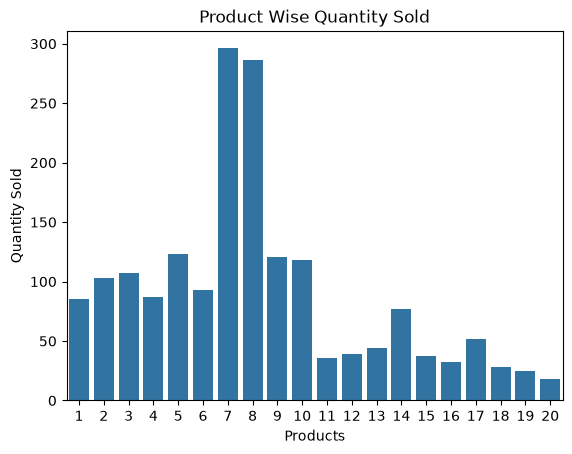

In [83]:
# Create the barplot
sns.barplot(data =product_quantity_df, 
            x= 'ProductID', 
            y= 'Quantity' )

plt.title('Product Wise Quantity Sold')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')

### 16. Create a scatterplot that plots Total Revenue and Total Cost. The scatterplot should include:
* hue that indicates the Total Net Profit of the order
* a horizontal line that indicates the mean Total Revenue for comparison
* all relevant labels to the plot and axis

Text(0.5, 1.0, 'Total Revenue vs Total Cost')

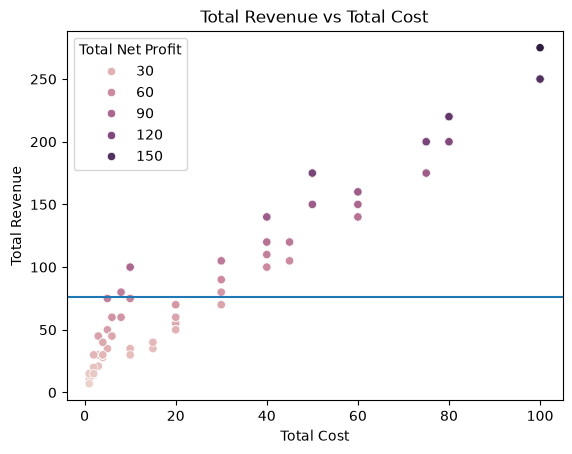

In [84]:
sns.scatterplot(data=orders_df, 
            x='Total Cost', 
            y='Total Revenue',
            hue='Total Net Profit')

plt.axhline(y=np.nanmean(orders_df['Total Revenue']))
plt.xlabel("Total Cost")
plt.ylabel("Total Revenue")
plt.title("Total Revenue vs Total Cost")

### 17. Create a horizontal barplot that shows the average Discount Pct for each City.

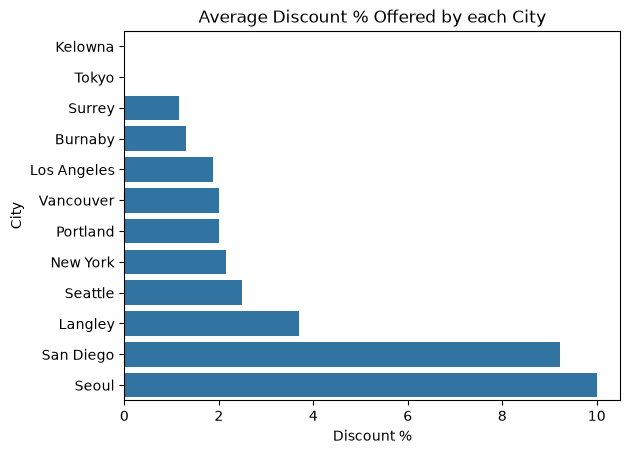

In [85]:
# Calculate the average Discount Pct by City. Sort the values by Discount Pct
city_discount_df = orders_df[['City','Discount Pct']].groupby(by='City').mean().sort_values(by='Discount Pct').reset_index()

# Create the barplot
sns.barplot(data=city_discount_df, 
            y='City', 
            x='Discount Pct', 
            orient='h') 

plt.xlabel("Discount %")
plt.ylabel("City")
plt.title("Average Discount % Offered by each City");

### 18. Create a lineplot that shows the Total Net Profit by Date.

Text(0, 0.5, 'Total Net Profit')

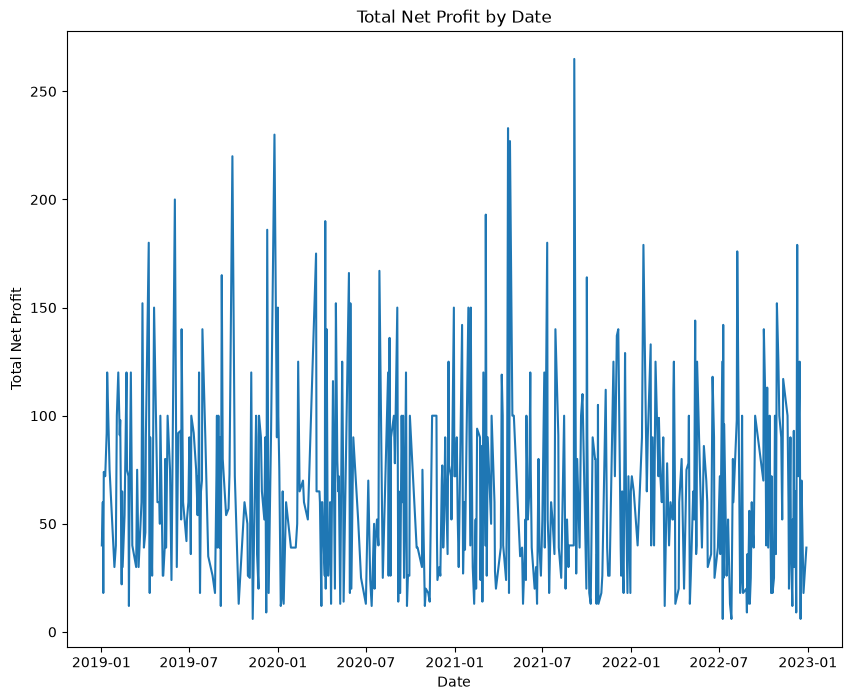

In [86]:
# Calculate Total Net Profit by Date
date_profit_df = orders_df[['Date','Total Net Profit']].groupby(by='Date').sum()

# Set the plot area
plt.figure(figsize=(10, 8))

# Create the lineplot
sns.lineplot(data = date_profit_df,
             x='Date',
             y='Total Net Profit')

plt.title("Total Net Profit by Date")
plt.xlabel("Date")
plt.ylabel("Total Net Profit")

### 19. Create a heatmap to visualize the correlation of columns in order_df.

<Axes: >

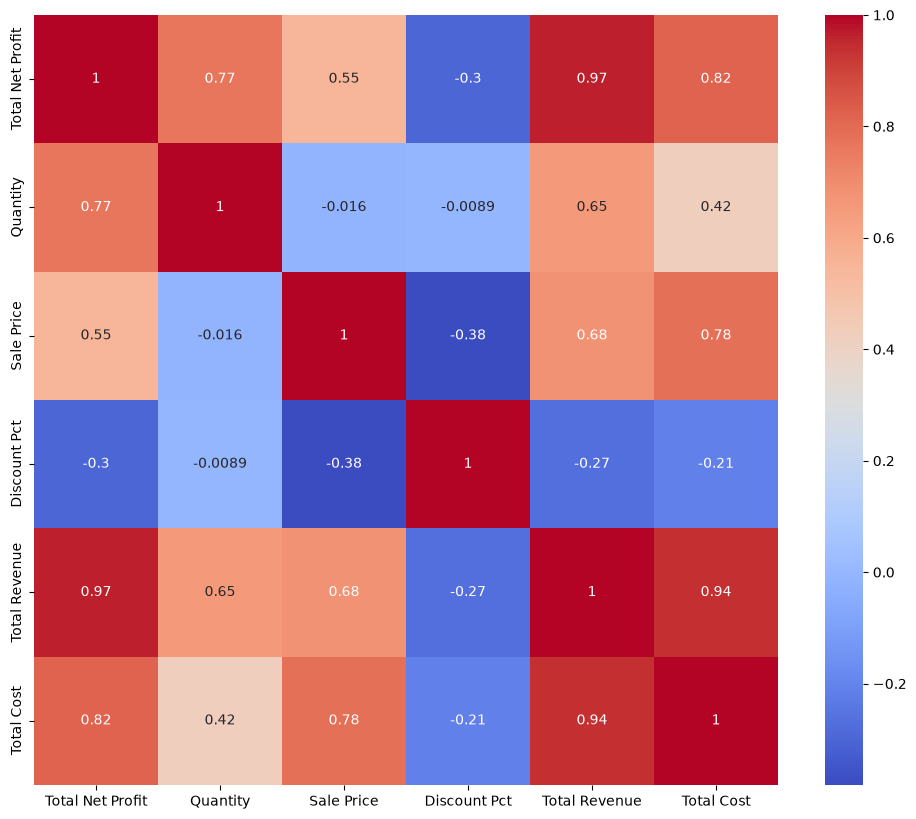

In [87]:
# Define the columns to include in correlation
corr_df = orders_df[['Total Net Profit', 'Quantity', 'Sale Price', 'Discount Pct','Total Revenue', 'Total Cost']]

# Calculate the correlation matrix
corr_matrix = corr_df.corr()

# Create the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

### 20a. Create a boxplot to identify any outliers in Total Revenue for each Type.

Text(0, 0.5, 'Quantity')

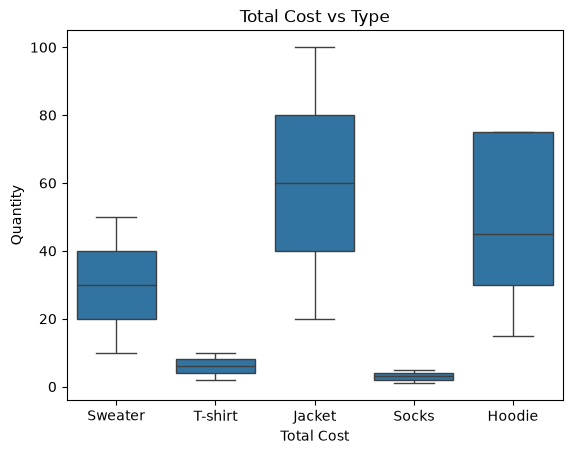

In [88]:
sns.boxplot(data=orders_df, 
            x='Type', 
            y='Total Cost')

plt.title("Total Cost vs Type")
plt.xlabel("Total Cost")
plt.ylabel("Quantity")

### 20b. Further explore the outliers identified in the visual and use the IQR rule to return the outlier rows from orders_df.

In [89]:
# Explore the descriptive statistics for the Type that contains the outliers
orders_df[orders_df['Type'] == 'Socks']['Total Revenue'].describe()

count    68.000000
mean     26.352941
std      16.200023
min       7.000000
25%      14.000000
50%      21.000000
75%      31.250000
max      75.000000
Name: Total Revenue, dtype: float64

In [91]:
# Calculate the IQR rule for this type to identify the outlier rows
q3 = 31.35
q1 = 14
IQR = q3 - q1
IQR_rule = 1.5*IQR
socks_df = orders_df[orders_df['Type'] == 'Socks']

# Return the outlier rows
socks_df[socks_df['Total Revenue'] >= (q3 + IQR_rule)]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
79,12,2019,7,6,5,80,80,"Socks,Black",15,1,...,Vancouver,Standard,3,2019-07-06,0,15.0,14.0,75.0,5,70.0
207,12,2020,7,6,5,211,211,"Socks,Black",15,1,...,Langley,Standard,2,2020-07-06,0,15.0,14.0,75.0,5,70.0
453,12,2022,6,5,5,499,499,"Socks,Black",15,1,...,Vancouver,Standard,3,2022-06-05,0,15.0,14.0,75.0,5,70.0
547,12,2022,12,19,5,599,599,"Socks,Black",15,1,...,Langley,Standard,2,2022-12-19,0,15.0,14.0,75.0,5,70.0


In [95]:
orders_df.to_excel('orders_data.xlsx', index=False)